# Matplotlib 使用教程

Matplotlib 是 Python 中最流行的数据可视化库，适用于量化交易数据分析。


## 1. 基础配置


In [5]:
import numpy as np
from matplotlib import pyplot as plt

# 图表样式
plt.style.use('seaborn-v0_8-darkgrid')


In [6]:
from matplotlib import pyplot as plt
import matplotlib
a=sorted([f.name for f in matplotlib.font_manager.fontManager.ttflist])

for i in a:
    print(i)


?????
Adwaita Mono
Adwaita Mono
Adwaita Mono
Adwaita Mono
Adwaita Sans
Adwaita Sans
Cantarell
DejaVu Math TeX Gyre
DejaVu Sans
DejaVu Sans
DejaVu Sans
DejaVu Sans
DejaVu Sans
DejaVu Sans
DejaVu Sans
DejaVu Sans
DejaVu Sans
DejaVu Sans
DejaVu Sans
DejaVu Sans
DejaVu Sans
DejaVu Sans Display
DejaVu Sans Mono
DejaVu Sans Mono
DejaVu Sans Mono
DejaVu Sans Mono
DejaVu Sans Mono
DejaVu Sans Mono
DejaVu Sans Mono
DejaVu Sans Mono
DejaVu Serif
DejaVu Serif
DejaVu Serif
DejaVu Serif
DejaVu Serif
DejaVu Serif
DejaVu Serif
DejaVu Serif
DejaVu Serif
DejaVu Serif
DejaVu Serif
DejaVu Serif
DejaVu Serif Display
Douyin Sans
Feibo Zheng Dots
Fira Code
Fira Code
Fira Code
Fira Code
Fira Code
Fira Code
Fira Code
Fira Code
Fira Code
Fira Code
Fira Code
Fira Code
Fira Code
FontQu Smile
FontQu Smile
Hack
Hack
Hack
Hack
Hack Nerd Font
Hack Nerd Font
Hack Nerd Font
Hack Nerd Font
Hack Nerd Font Mono
Hack Nerd Font Mono
Hack Nerd Font Mono
Hack Nerd Font Mono
Hack Nerd Font Propo
Hack Nerd Font Propo
Hack Nerd

In [7]:
plt.rcParams['font.family'] = 'Source Han Serif CN'  # 替换为你选择的字体


## 2. 基础折线图


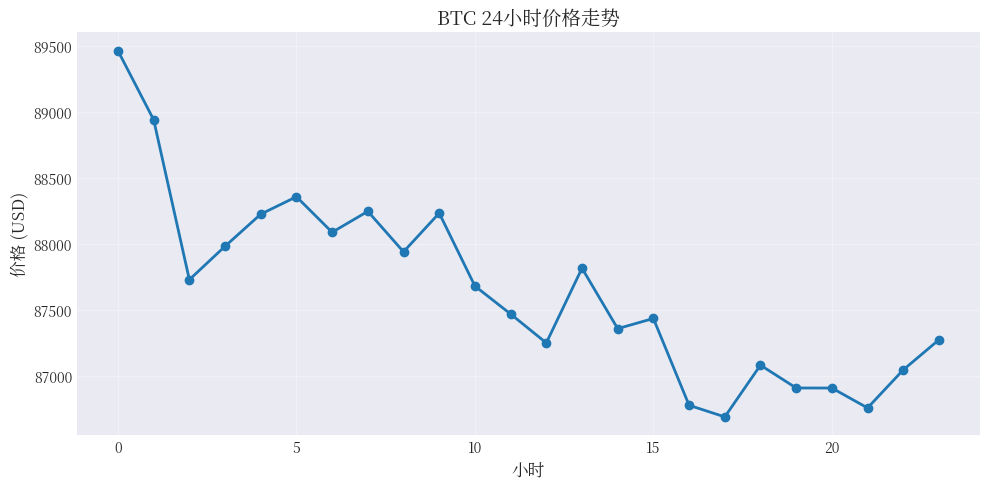

In [8]:
# 模拟价格数据
x = np.arange(0, 24, 1)
price = 90000 + np.cumsum(np.random.randn(24) * 500)

plt.figure(figsize=(10, 5))
plt.plot(x, price, marker='o', linewidth=2, color='#1f77b4')
plt.title('BTC 24小时价格走势', fontsize=14)
plt.xlabel('小时', fontsize=12)
plt.ylabel('价格 (USD)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. 多条线对比


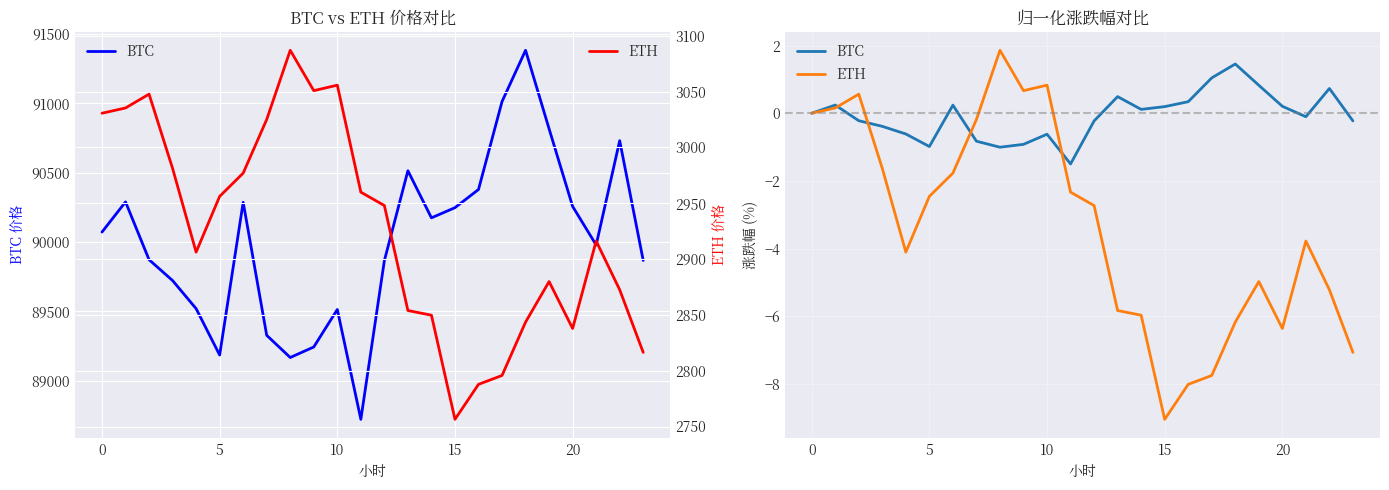

In [9]:
btc = 90000 + np.cumsum(np.random.randn(24) * 500)
eth = 3000 + np.cumsum(np.random.randn(24) * 50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：双Y轴
ax1_twin = ax1.twinx()
ax1.plot(x, btc, 'b-', label='BTC', linewidth=2)
ax1_twin.plot(x, eth, 'r-', label='ETH', linewidth=2)
ax1.set_xlabel('小时')
ax1.set_ylabel('BTC 价格', color='b')
ax1_twin.set_ylabel('ETH 价格', color='r')
ax1.set_title('BTC vs ETH 价格对比')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

# 右图：归一化对比
btc_norm = (btc - btc[0]) / btc[0] * 100
eth_norm = (eth - eth[0]) / eth[0] * 100
ax2.plot(x, btc_norm, label='BTC', linewidth=2)
ax2.plot(x, eth_norm, label='ETH', linewidth=2)
ax2.set_xlabel('小时')
ax2.set_ylabel('涨跌幅 (%)')
ax2.set_title('归一化涨跌幅对比')
ax2.legend()
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. K 线图（蜡烛图）


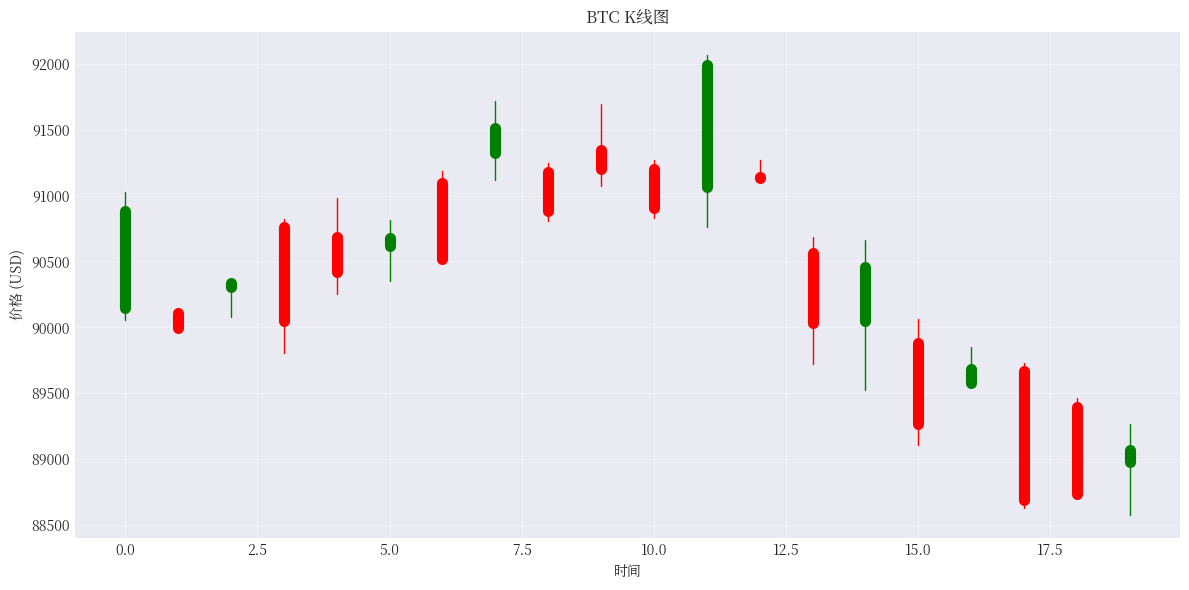

In [10]:
# 模拟OHLC数据
np.random.seed(42)
opens = 90000 + np.cumsum(np.random.randn(20) * 300)
closes = opens + np.random.randn(20) * 500
highs = np.maximum(opens, closes) + np.abs(np.random.randn(20) * 200)
lows = np.minimum(opens, closes) - np.abs(np.random.randn(20) * 200)

fig, ax = plt.subplots(figsize=(12, 6))

for i in range(len(opens)):
    color = 'g' if closes[i] >= opens[i] else 'r'
    # 实体
    ax.plot([i, i], [opens[i], closes[i]], color=color, linewidth=8, solid_capstyle='round')
    # 影线
    ax.plot([i, i], [lows[i], highs[i]], color=color, linewidth=1)

ax.set_xlabel('时间')
ax.set_ylabel('价格 (USD)')
ax.set_title('BTC K线图')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. 柱状图 - 清算数据可视化


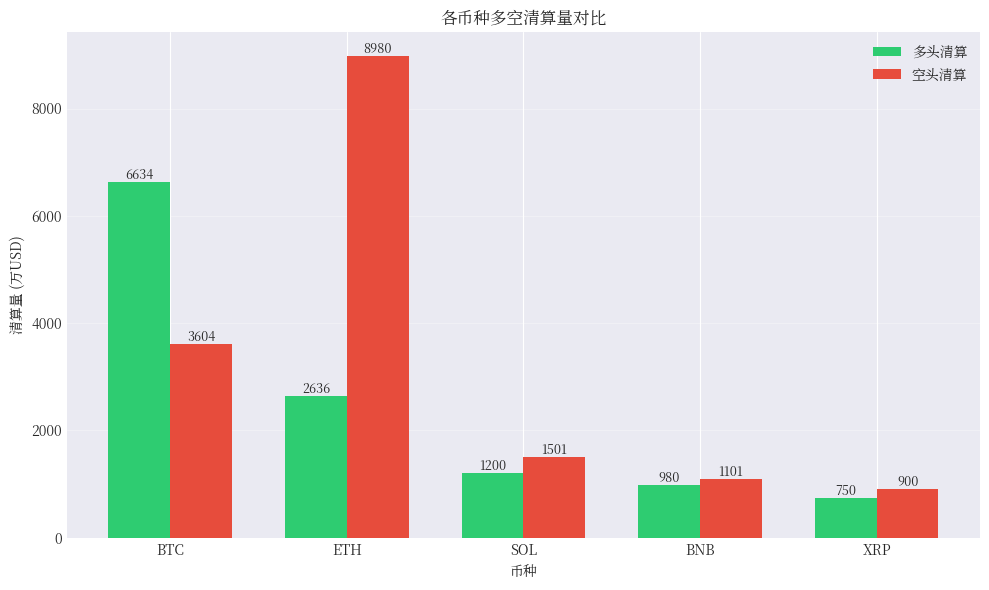

In [11]:
# 模拟清算数据
symbols = ['BTC', 'ETH', 'SOL', 'BNB', 'XRP']
long_amt = [6633.86, 2635.54, 1200.5, 980.3, 750.2]
short_amt = [3604.13, 8980.18, 1500.8, 1100.6, 900.4]

x_pos = np.arange(len(symbols))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x_pos - width/2, long_amt, width, label='多头清算', color='#2ecc71')
bars2 = ax.bar(x_pos + width/2, short_amt, width, label='空头清算', color='#e74c3c')

ax.set_xlabel('币种')
ax.set_ylabel('清算量 (万USD)')
ax.set_title('各币种多空清算量对比')
ax.set_xticks(x_pos)
ax.set_xticklabels(symbols)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## 6. 饼图 - 持仓分布


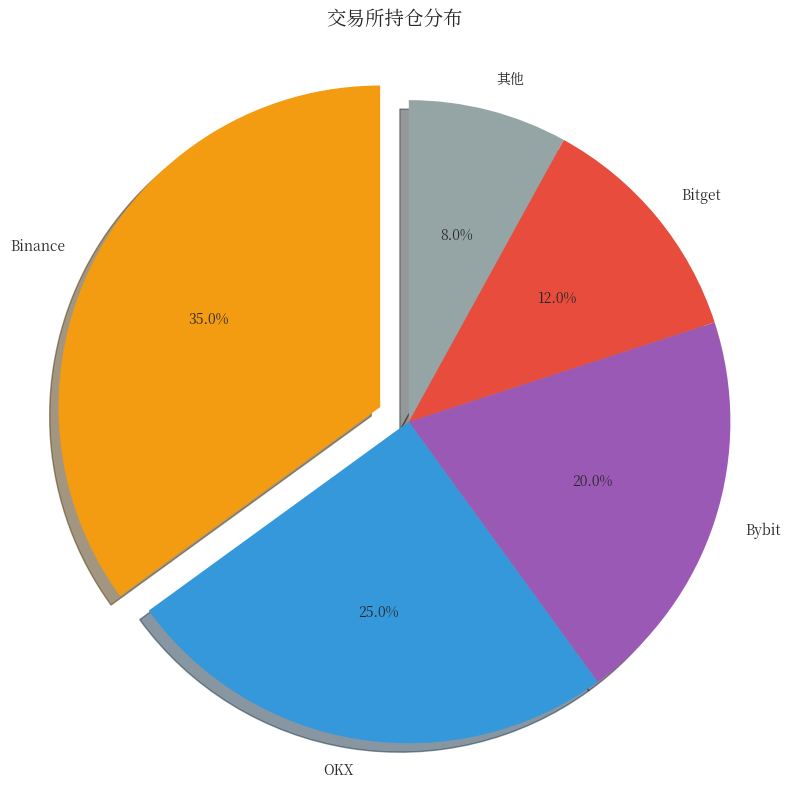

In [12]:
exchanges = ['Binance', 'OKX', 'Bybit', 'Bitget', '其他']
volumes = [35, 25, 20, 12, 8]
colors = ['#f39c12', '#3498db', '#9b59b6', '#e74c3c', '#95a5a6']
explode = (0.1, 0, 0, 0, 0)

plt.figure(figsize=(8, 8))
plt.pie(volumes, labels=exchanges, autopct='%1.1f%%', startangle=90,
        colors=colors, explode=explode, shadow=True)
plt.title('交易所持仓分布', fontsize=14, pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()


## 7. 散点图 - 价格与成交量关系


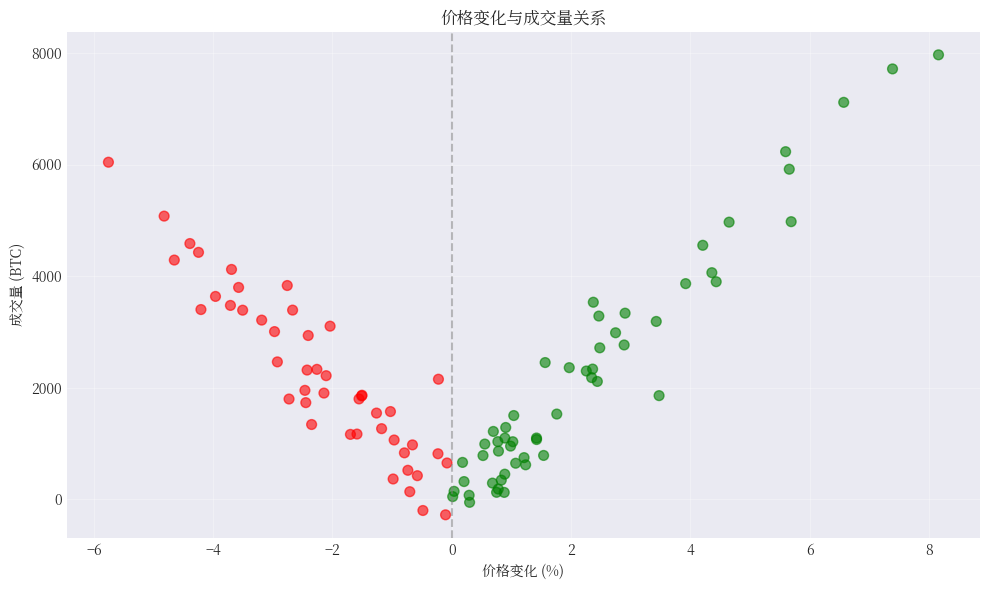

In [13]:
price_change = np.random.randn(100) * 3
volume = np.abs(price_change) * 1000 + np.random.randn(100) * 500
colors_scatter = ['r' if p < 0 else 'g' for p in price_change]

plt.figure(figsize=(10, 6))
plt.scatter(price_change, volume, c=colors_scatter, alpha=0.6, s=50)
plt.xlabel('价格变化 (%)')
plt.ylabel('成交量 (BTC)')
plt.title('价格变化与成交量关系')
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. 热力图 - 相关性矩阵


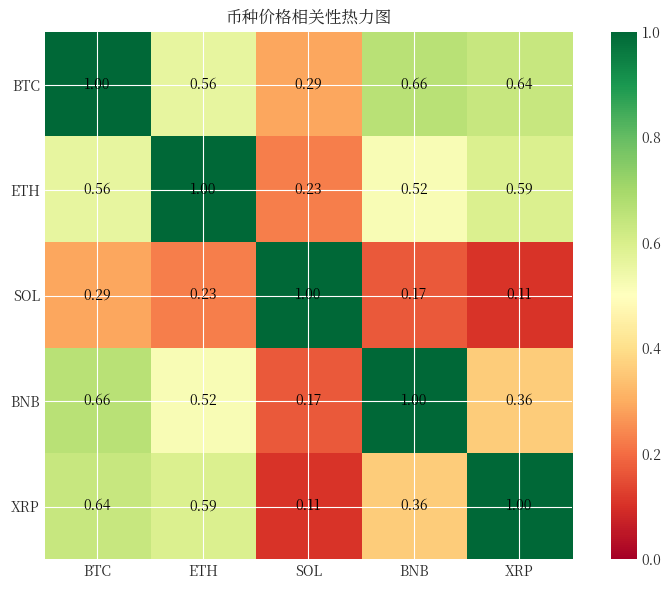

In [14]:
# 模拟相关性数据
coins = ['BTC', 'ETH', 'SOL', 'BNB', 'XRP']
corr_matrix = np.random.rand(5, 5)
corr_matrix = (corr_matrix + corr_matrix.T) / 2
np.fill_diagonal(corr_matrix, 1)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(np.arange(len(coins)))
ax.set_yticks(np.arange(len(coins)))
ax.set_xticklabels(coins)
ax.set_yticklabels(coins)

# 添加数值
for i in range(len(coins)):
    for j in range(len(coins)):
        text = ax.text(j, i, f'{corr_matrix[i, j]:.2f}',
                      ha='center', va='center', color='black')

ax.set_title('币种价格相关性热力图')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 9. 子图布局 - 综合仪表盘


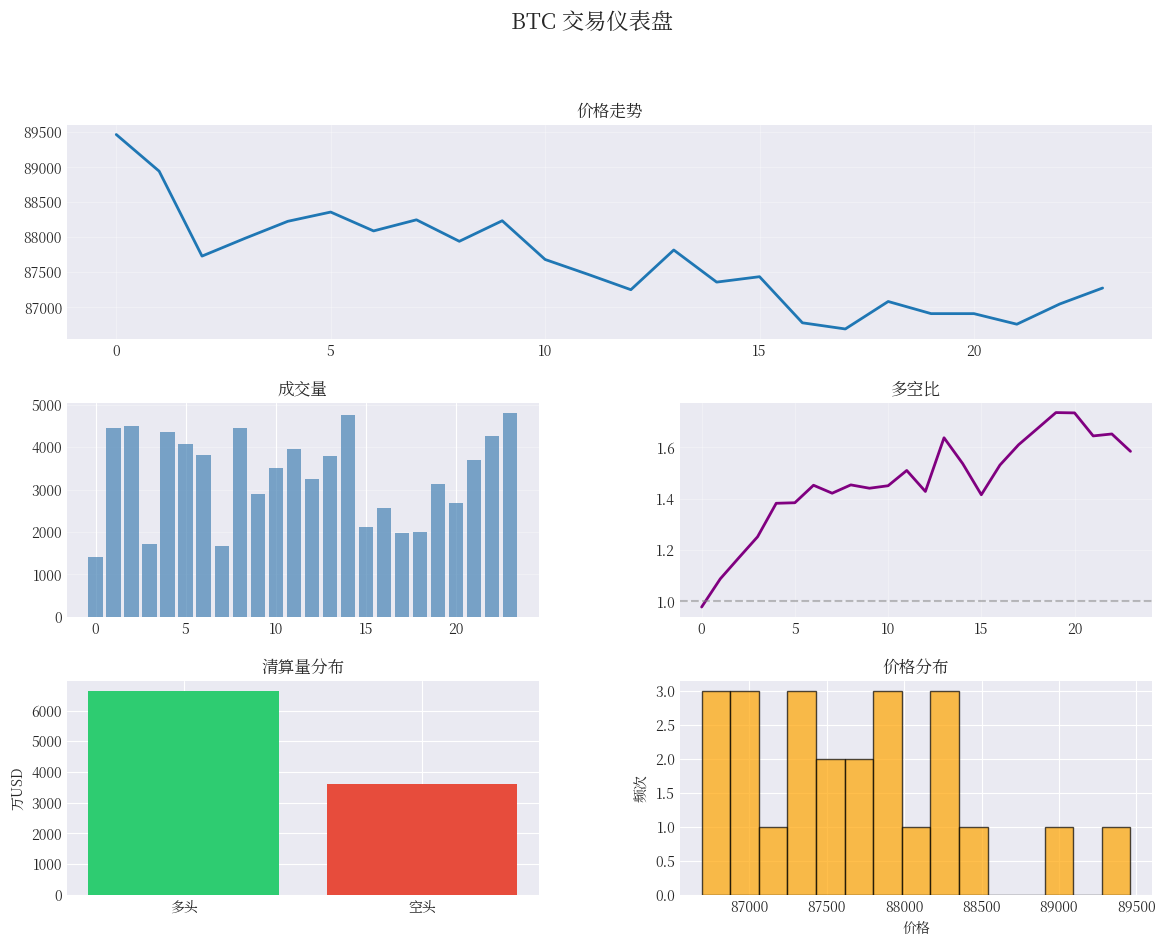

In [15]:
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 价格走势
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(x, price, linewidth=2)
ax1.set_title('价格走势')
ax1.grid(True, alpha=0.3)

# 成交量
ax2 = fig.add_subplot(gs[1, 0])
volume_data = np.random.randint(1000, 5000, 24)
ax2.bar(x, volume_data, color='steelblue', alpha=0.7)
ax2.set_title('成交量')
ax2.grid(True, alpha=0.3, axis='y')

# 多空比
ax3 = fig.add_subplot(gs[1, 1])
long_short_ratio = 1 + np.cumsum(np.random.randn(24) * 0.1)
ax3.plot(x, long_short_ratio, color='purple', linewidth=2)
ax3.axhline(1, color='gray', linestyle='--', alpha=0.5)
ax3.set_title('多空比')
ax3.grid(True, alpha=0.3)

# 清算分布
ax4 = fig.add_subplot(gs[2, 0])
ax4.bar(['多头', '空头'], [6633.86, 3604.13], color=['#2ecc71', '#e74c3c'])
ax4.set_title('清算量分布')
ax4.set_ylabel('万USD')

# 价格分布
ax5 = fig.add_subplot(gs[2, 1])
ax5.hist(price, bins=15, color='orange', alpha=0.7, edgecolor='black')
ax5.set_title('价格分布')
ax5.set_xlabel('价格')
ax5.set_ylabel('频次')

plt.suptitle('BTC 交易仪表盘', fontsize=16, y=0.995)
plt.show()


## 10. 保存图表


图表已保存


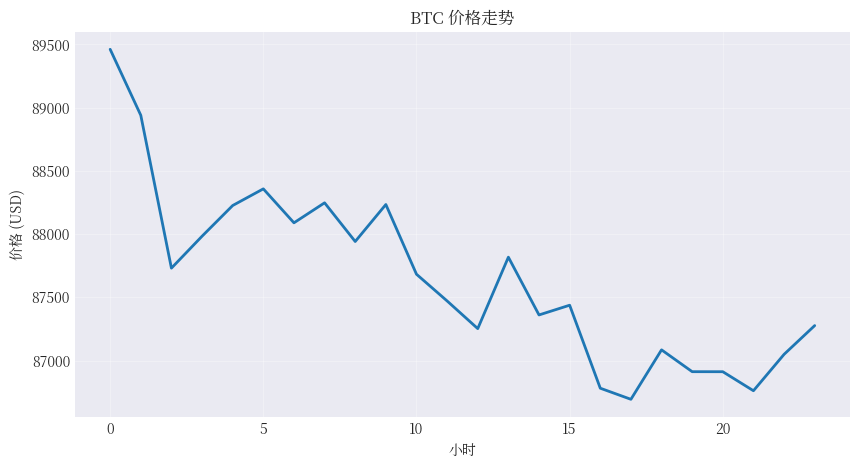

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(x, price, linewidth=2)
plt.title('BTC 价格走势')
plt.xlabel('小时')
plt.ylabel('价格 (USD)')
plt.grid(True, alpha=0.3)

# 保存为不同格式
plt.savefig('btc_price.png', dpi=300, bbox_inches='tight')
plt.savefig('btc_price.pdf', bbox_inches='tight')
print(f"图表已保存")
plt.show()


## 11. 实战案例：最大痛苦点可视化


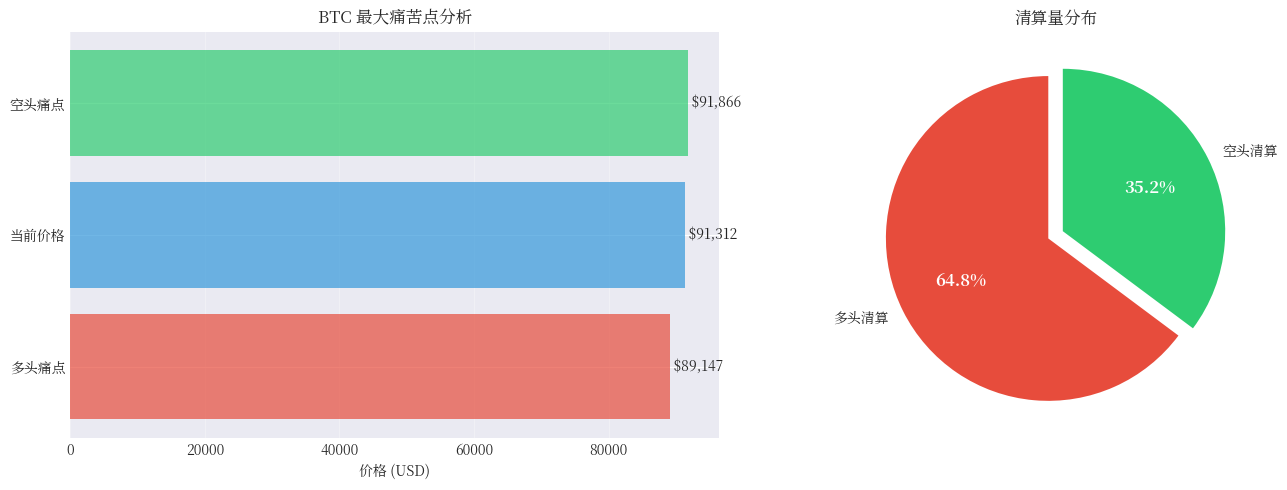

多空比: 1.84:1
价格距离多头痛点: 2.43%
价格距离空头痛点: 0.61%


In [17]:
# 模拟最大痛苦点数据
max_pain_data = {
    'price': 91312.3,
    'short_pain': 91866.37,
    'short_amt': 3604.13,
    'long_pain': 89146.9,
    'long_amt': 6633.86
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：价格与痛点位置
positions = ['多头痛点', '当前价格', '空头痛点']
prices = [max_pain_data['long_pain'], max_pain_data['price'], max_pain_data['short_pain']]
colors_pain = ['#e74c3c', '#3498db', '#2ecc71']

bars = ax1.barh(positions, prices, color=colors_pain, alpha=0.7)
ax1.set_xlabel('价格 (USD)')
ax1.set_title('BTC 最大痛苦点分析')
ax1.grid(True, alpha=0.3, axis='x')

for i, (bar, price) in enumerate(zip(bars, prices)):
    ax1.text(price, i, f' ${price:,.0f}', va='center', fontsize=10)

# 右图：清算量对比
labels = ['多头清算', '空头清算']
amounts = [max_pain_data['long_amt'], max_pain_data['short_amt']]
colors_amt = ['#e74c3c', '#2ecc71']

wedges, texts, autotexts = ax2.pie(amounts, labels=labels, autopct='%1.1f%%',
                                     colors=colors_amt, startangle=90, explode=(0.05, 0.05))
ax2.set_title('清算量分布')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_weight('bold')

plt.tight_layout()
plt.show()

print(f"多空比: {max_pain_data['long_amt']/max_pain_data['short_amt']:.2f}:1")
print(f"价格距离多头痛点: {((max_pain_data['price']-max_pain_data['long_pain'])/max_pain_data['long_pain']*100):.2f}%")
print(f"价格距离空头痛点: {((max_pain_data['short_pain']-max_pain_data['price'])/max_pain_data['price']*100):.2f}%")
